In [2]:
from tensorflow.keras.datasets import mnist
from keras import Sequential
from keras.layers import Dense, Flatten,Conv2D, MaxPooling2D
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

#Display dataset shapes
print(f"x_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


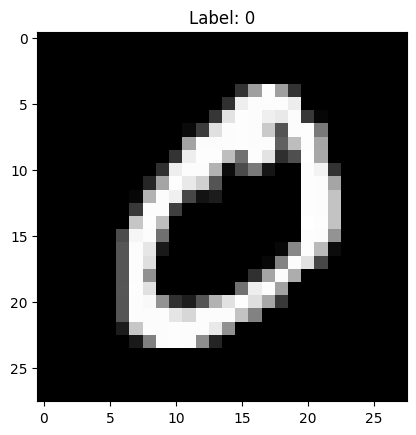

In [4]:
#Basic Data Visualization
img=X_train[1,:,:]
label=y_train[1]
plt.imshow(img,cmap='gray')
plt.title(f'Label: {label}')
plt.show()

In [5]:
#Normalize and reshape the data
X_train=X_train.reshape(-1,28,28,1).astype('float32')/255
X_test=X_test.reshape(-1,28,28,1).astype('float32')/255

#One-hot encode the labels
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)

In [6]:
#Build the CNN model
model=Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])
model.summary()

c:\Users\Nihal - Pooju\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [9]:
history=model.fit(X_train,y_train,epochs=5,batch_size=128,validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9305 - loss: 0.2349 - val_accuracy: 0.9786 - val_loss: 0.0747
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9810 - loss: 0.0606 - val_accuracy: 0.9751 - val_loss: 0.0853
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9860 - loss: 0.0442 - val_accuracy: 0.9858 - val_loss: 0.0483
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9892 - loss: 0.0339 - val_accuracy: 0.9868 - val_loss: 0.0466
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9912 - loss: 0.0272 - val_accuracy: 0.9883 - val_loss: 0.0390


In [13]:
#Model Evaluation
test_loss,test_accuracy=model.evaluate(X_test,y_test)
print(f"Test Loss:{test_loss}")
print(f"Test Accuracy:{test_accuracy}")



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9899 - loss: 0.0316
Test Loss:0.031614262610673904
Test Accuracy:0.9898999929428101


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


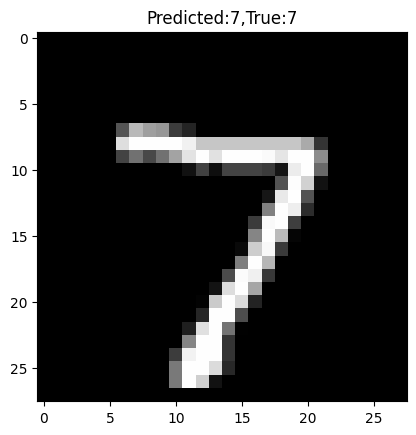

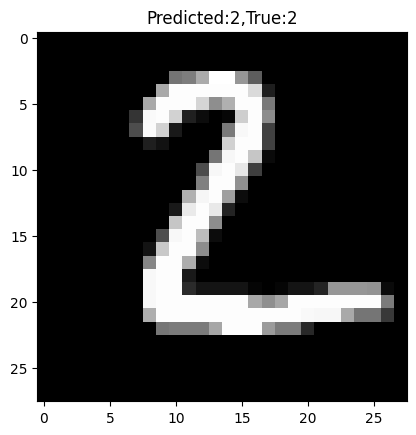

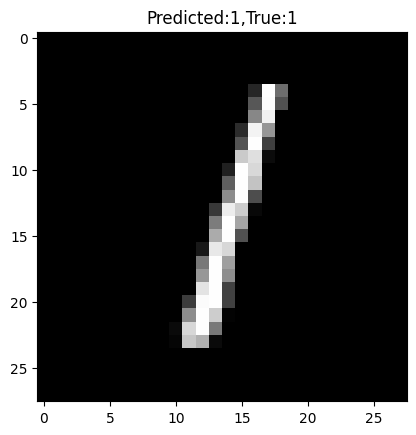

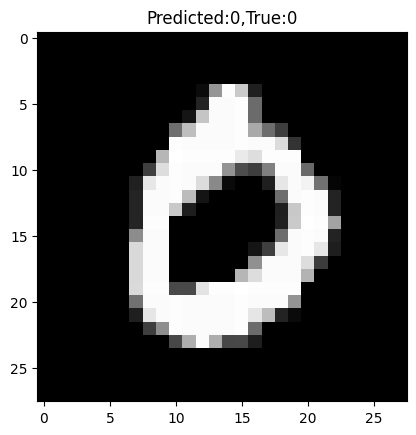

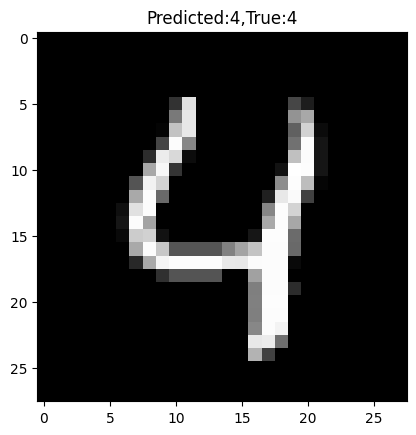

In [14]:
predictions=model.predict(X_test[:5])
predicted_classes=np.argmax(predictions,axis=1)
true_classes=np.argmax(y_test[:5],axis=1)

for i in range(5):
    plt.imshow(X_test[i].reshape(28,28),cmap='gray')
    plt.title(f"Predicted:{predicted_classes[i]},True:{true_classes[i]}")
    plt.show()